In [1]:
import os, sys
sys.path.insert(0, "/home/pzanders/Documents/BSC/BioExcel/biobb/biobb_dyna")
os.chdir("/home/pzanders/Documents/BSC/BioExcel/biobb/biobb_dyna")


In [2]:
# Imports
from biobb_dyna.dyna.analysis.plots import *

# Correlation Matrix Computation

In [3]:
from biobb_dyna.dyna.dyncorr.dccm import compute_dccm

prop = {
    'matrix_type': 'correlation',
    'selection': 'name CA',
    'dynamics_type': 'displacements',
    'num_replicas': 1,
    'system_selstr': 'protein',
    'align_selection': None,
    'in_mem': True,
    'reference': None,
    'stride_initial': 0,
    'stride_final': -1,
    'stride_step': 1,
    'scale': True,
    'normalize': True,
    'lmi': None,
    'mi': 'None',
    'dcc': False,
    'pcc': False,
    'cov_disp': False,
    'verbose': True,
    'mean_center': True,
    'center': None,
    'subset': None
}

input_traj_path = "biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.xtc"
input_top_path  = "biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.pdb"
output_matrix_path = "output_matrix.npz"

compute_dccm(input_traj_path=input_traj_path,
             input_top_path=input_top_path,
             output_matrix_path=output_matrix_path,
             properties=prop)


2025-10-20 18:16:43,106 [MainThread  ] [INFO ]  Executing Dccm with matrix_type: correlation


/home/pzanders/miniconda3/envs/mdaenv/lib/python3.12/site-packages/Bio/Application/__init__.py:40: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
/home/pzanders/miniconda3/envs/mdaenv/lib/python3.12/site-packages/biobb_common/tools/file_utils.py:789: UserWarning: biobb_dyna.dyna.dyncorr.dccm input_traj_path: biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.xtc extension is not in the valid extensions list: ['dcd']. If you want to suppress this message, please set the check_extensions property to False
  warnings.warn(not_valid_extension_error_string)


  0%|          | 0/2501 [00:00<?, ?it/s]

@>: total number of frames in trajectory file: 2501
@>: length of selected trajectory segment:     2501
@>: number of replicas:                     1
@>: using window length of 2501 simulation steps
@>: number or frames per replica:           2501
@>: first frame:                            0
@>: last frame:                             2501
@>: actual last frame:                      2501
@>: step:                                   1
@>: number of residues in selected atom group: 517
@>: number of nodes    in selected atom group: 517
@>: number of elements in selected atom group: 517
@>: sanity check pass: number of residues is same as number of nodes
@> -- shape of coordinates matrix: (1, 2501, 517, 3)
@> -- shape of coordinates_allreplicas matrix: (1, 2501, 1551)
@> -- shape of displacements_allreplicas matrix: (1, 2501, 1551)
@> -- shape of disp_from_mean_allreplicas matrix: (1, 2501, 517)
@> -- shape of distances_allreplicas matrix: (1, 517, 517)
@> -- shape of covar_disp_allreplic

@>: LMI/MI calculation ...
@>: begin frame: 0
@>: end   frame: 2501
@>: step:        1
@>: reshaping coordinates...
@>: computing and storing distances...
@>: computing normalized dynamical cross-correlation matrix
@>: computing and storing distances...
@>: computing normalized dynamical cross-correlation matrix
2025-10-20 18:16:47,971 [MainThread  ] [INFO ]  Computation complete.
2025-10-20 18:16:47,971 [MainThread  ] [INFO ]  Computation complete.


0

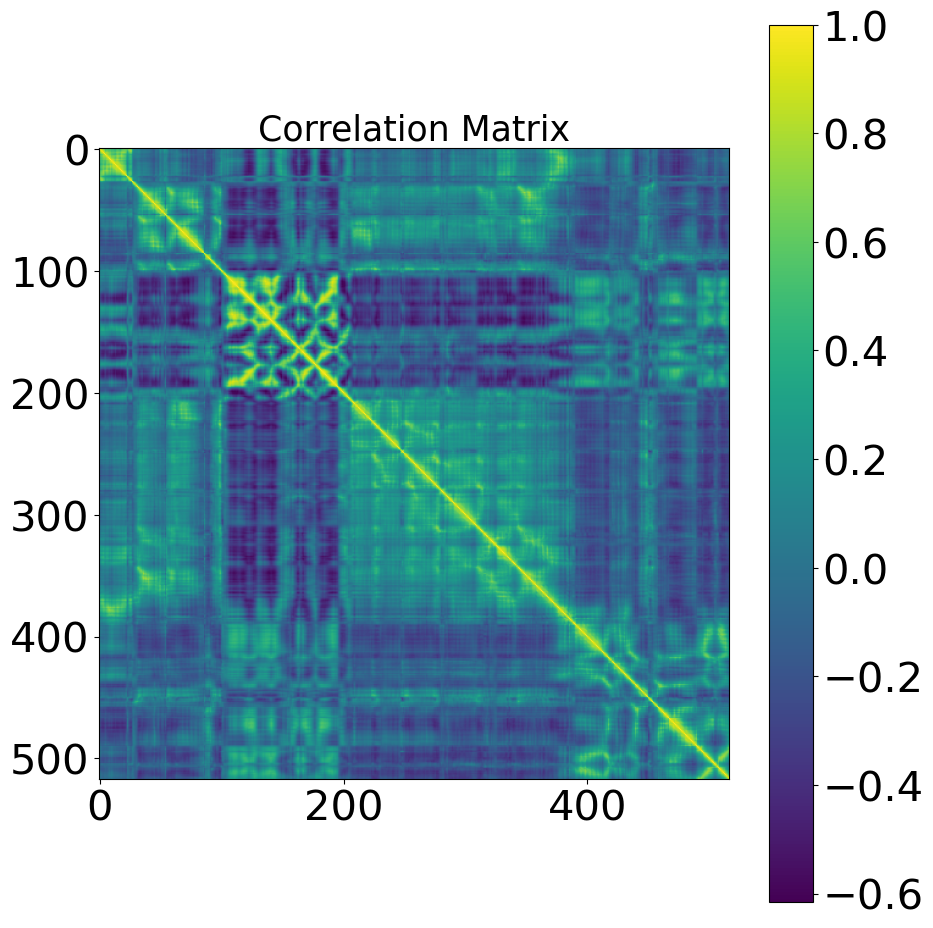

In [6]:
plot_dccm(
    dccm_result_path="output_matrix.npz",
)

# Network Graph Construction

In [8]:
from biobb_dyna.dyna.network.create_graph import create_graph

prop = {
    'selection': "name CA",   # Atom selection
    'corr_threshold': 0.5,    # correlation threshold
    'use_abs': True,          # Use absolute values for edges
    'loc_factor': 12.0,        # Only consider atoms within distance threshold of 5A
    'prune_mode': "greater",  # Pruning mode: 'greater' (prune distances > loc_factor), 'lower' (prune < loc_factor), 'none' (no pruning).
    'exclude_neighbors': 0    # Exclude edges between nodes with index difference <= this value (e.g., for sequential residues).
}

input_matrix_path = "output_matrix.npz"
input_top_path = "biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.pdb"
output_graph_path = "output_graph.graphml"

create_graph(input_matrix_path=input_matrix_path,
             input_top_path=input_top_path,
             output_graph_path=output_graph_path,
             properties=prop)


2025-10-20 18:05:52,833 [MainThread  ] [INFO ]  Executing NetworkFromMatrix
2025-10-20 18:05:52,901 [MainThread  ] [INFO ]  Network creation complete.


0

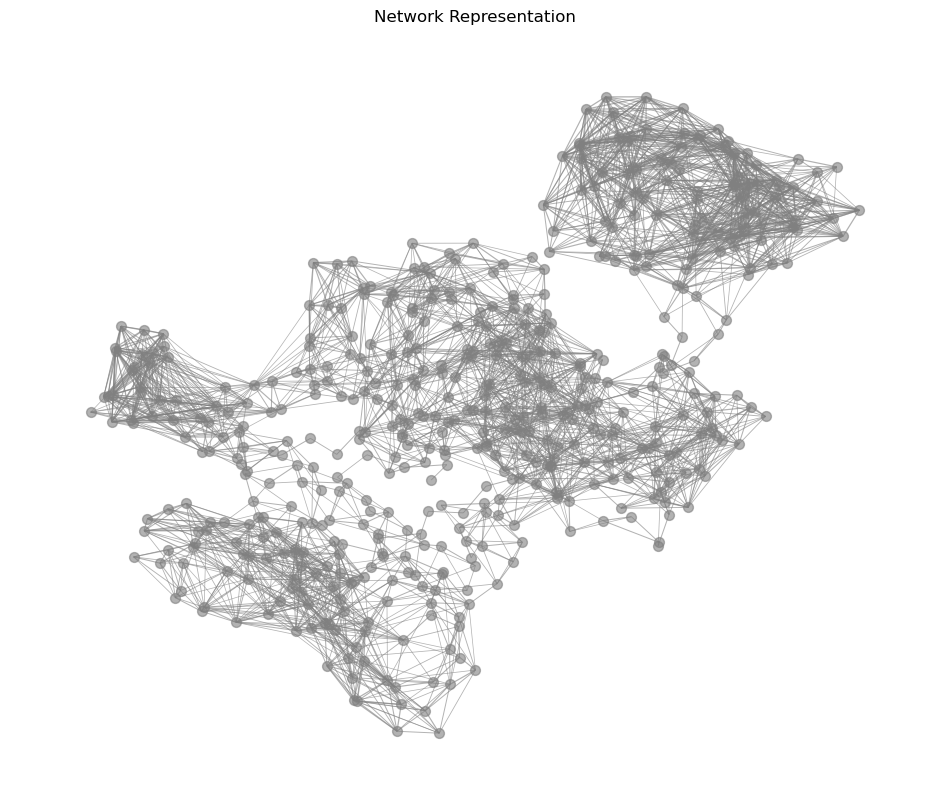

In [3]:
plot_network(
    graph_path="output_graph.graphml",
    input_top_path="biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.pdb",
)

# Network Analysis

## Node Betweenness

Node betweenness centrality measures how often a node (e.g., a residue) lies on the shortest paths between other nodes in the network. High betweenness indicates a node acts as a critical bridge or bottleneck for information flow, making it essential for allosteric communication; low betweenness suggests a peripheral or less controlling role in pathways. In MD analysis, it highlights "bottleneck" residues critical for information flow or allosteric communication, as they control pathways of dynamic coupling between distant sites.


In [11]:
from biobb_dyna.dyna.analysis.node_betweenness import node_betweenness

node_betweenness(input_graph_path='output_graph.graphml',
            output_betweenness_path='output_betweenness.json',
            properties={})


2025-10-20 16:24:25,600 [MainThread  ] [INFO ]  Executing Betweenness analysis
2025-10-20 16:24:26,160 [MainThread  ] [INFO ]  Betweenness analysis complete.


0

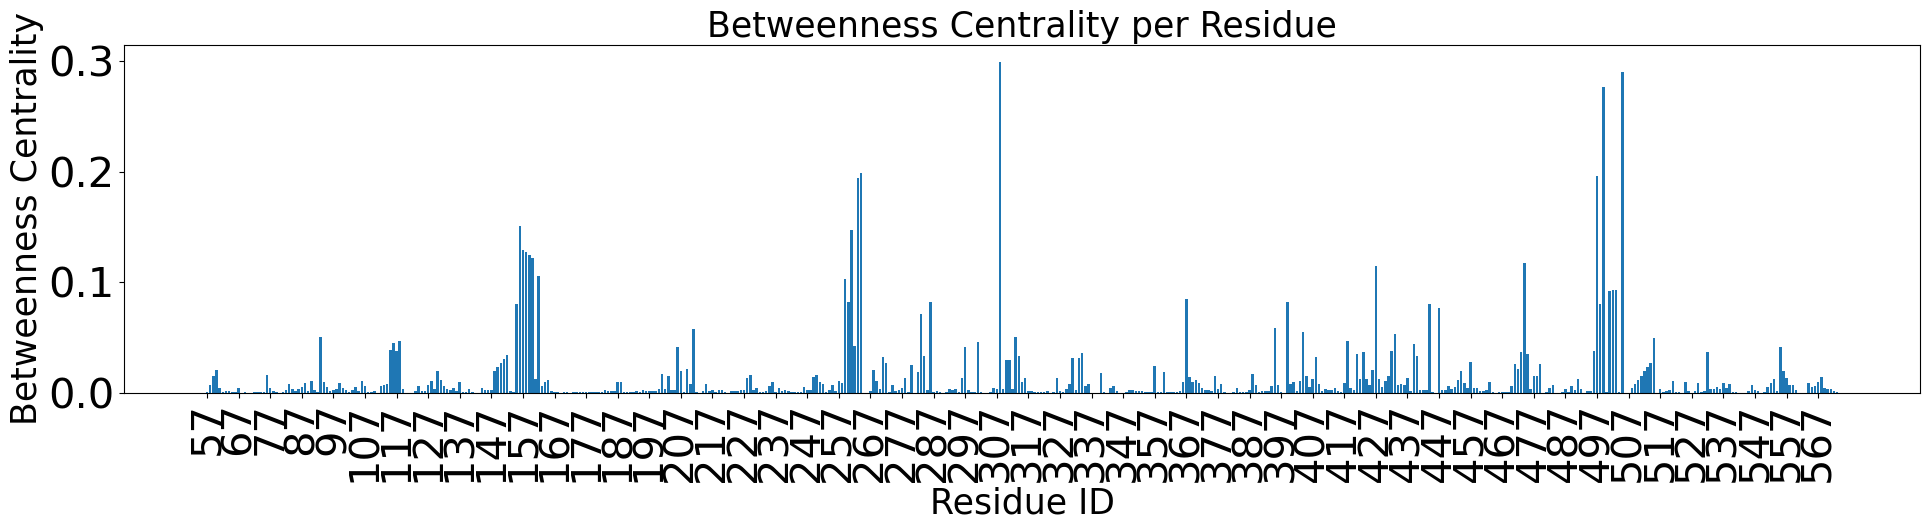

In [12]:
plot_betweenness(betweenness_result_path='output_betweenness.json')

## Eigenvector Centrality

Eigenvector centrality assesses a node's importance based on its connections to other high-centrality nodes, essentially capturing influence in the network. High eigenvector centrality means the node is well-connected to other influential nodes, marking it as a key hub in the network; low values indicate limited connectivity to central elements, suggesting lesser overall influence. In MD data, it's applied to identify key residues that are central to global dynamics, such as hubs in protein interaction networks that stabilize structures or propagate conformational changes.

In [13]:
from biobb_dyna.dyna.analysis.eigenvector_centrality import eigenvector_centrality

eigenvector_centrality(input_graph_path='output_graph.graphml',
            output_eigenvector_path='output_eigenvector_centrality.json',
            properties={})

2025-10-20 16:24:33,290 [MainThread  ] [INFO ]  Executing EigenvectorCentrality analysis
2025-10-20 16:24:33,361 [MainThread  ] [INFO ]  EigenvectorCentrality analysis complete.


0

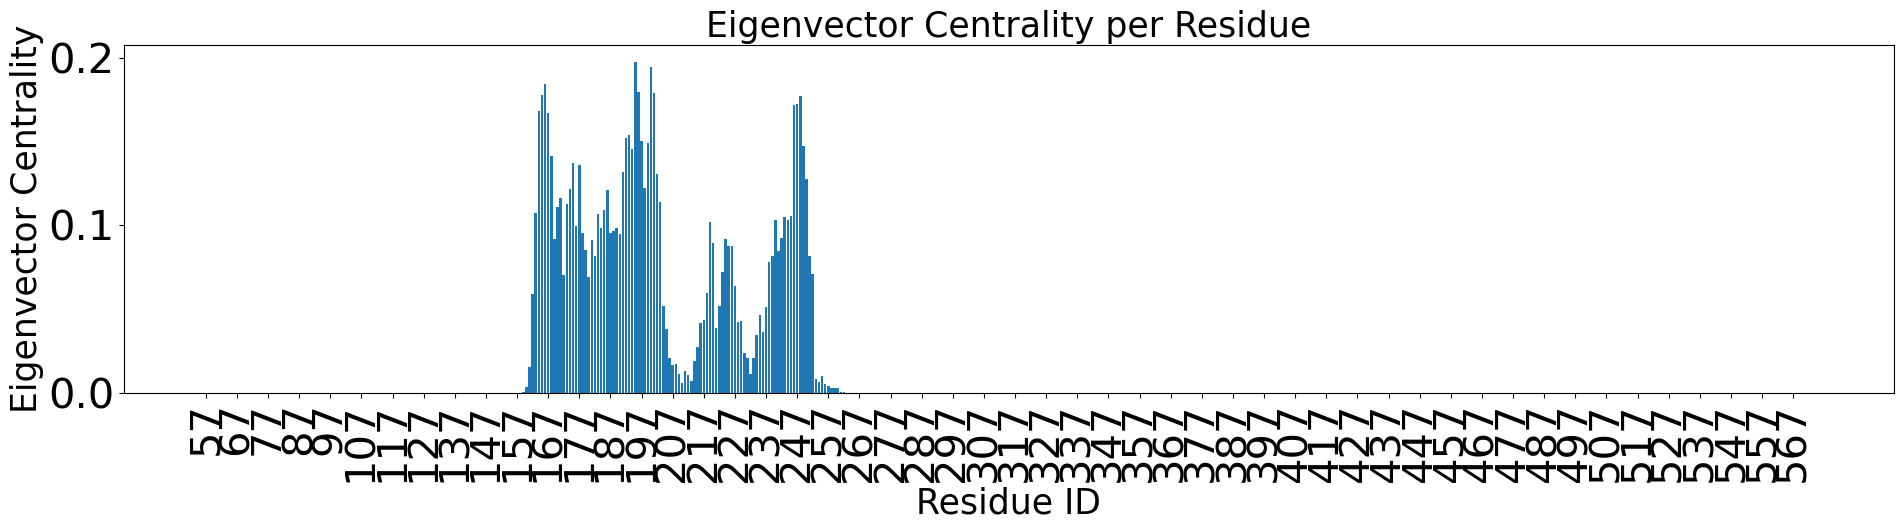

In [14]:
plot_eigenvector_centrality(eigenvector_centrality_result_path='output_eigenvector_centrality.json')

## Community Analysis

Community analysis in molecular dynamics (MD) data involves partitioning correlation or interaction networks (where nodes represent residues or atoms) into densely connected subgraphs or "communities." This helps identify functional modules in proteins, such as domains or allosteric sites, revealing how groups of residues move cooperatively during simulations.

In [15]:
from biobb_dyna.dyna.analysis.communities import communities

prop = {
    'algorithm': 'girvan_newman'
}

communities(input_graph_path='output_graph.graphml',
            output_communities_path='output_communities.json',
            properties=prop)


2025-10-20 16:24:37,522 [MainThread  ] [INFO ]  Executing Communities analysis with algorithm: girvan_newman
2025-10-20 16:27:42,463 [MainThread  ] [INFO ]  Communities analysis complete.


0

### Modularity

Community modularity quantifies the quality of these partitions by measuring the density of connections within communities versus between them (values range from 0 to 1, with higher indicating stronger structure). High modularity signifies a well-defined community structure with dense intra-community links and sparse inter-community connections, often reflecting biologically distinct functional units in proteins; low modularity suggests a more random or homogeneous network lacking clear modular organization. In MD, it's used to evaluate and optimize community detection, ensuring identified modules reflect biologically meaningful dynamic behaviors, like in protein folding or ligand binding.

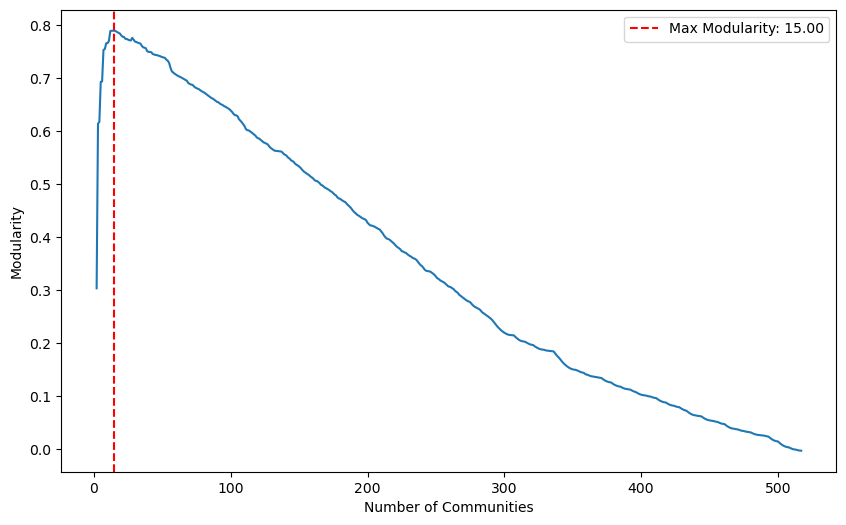

In [3]:
plot_community_modularity(communities_results_path="output_communities.json")

### Community visualization

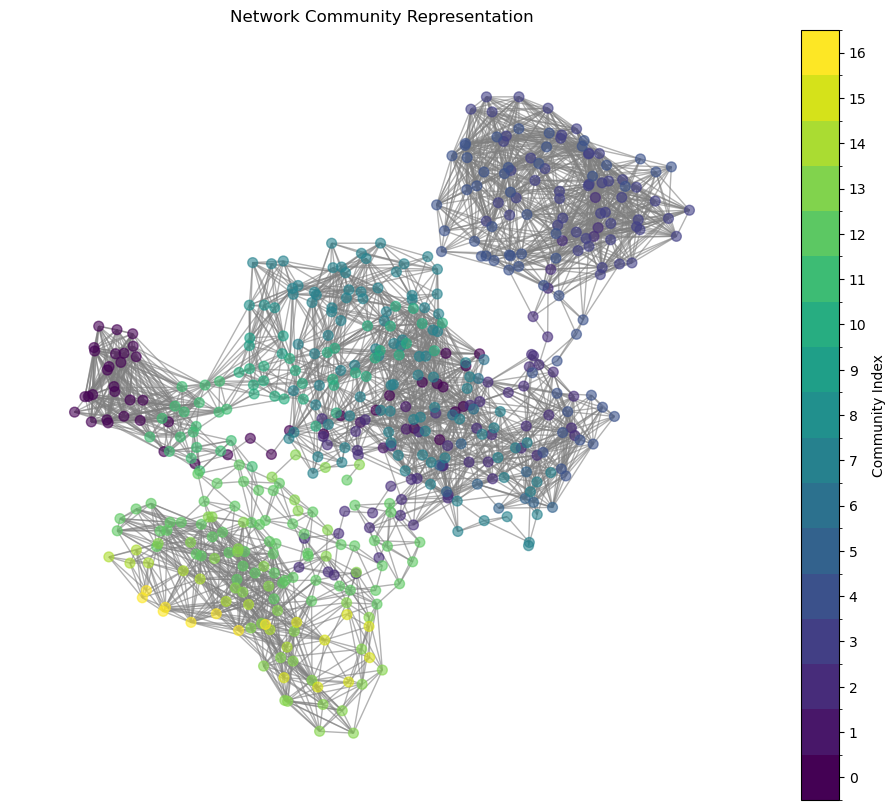

In [3]:
plot_communities(
    graph_path="output_graph.graphml",
    input_top_path="biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.pdb",
    communities_results_path="output_communities.json"
)

### Community partition dendogram

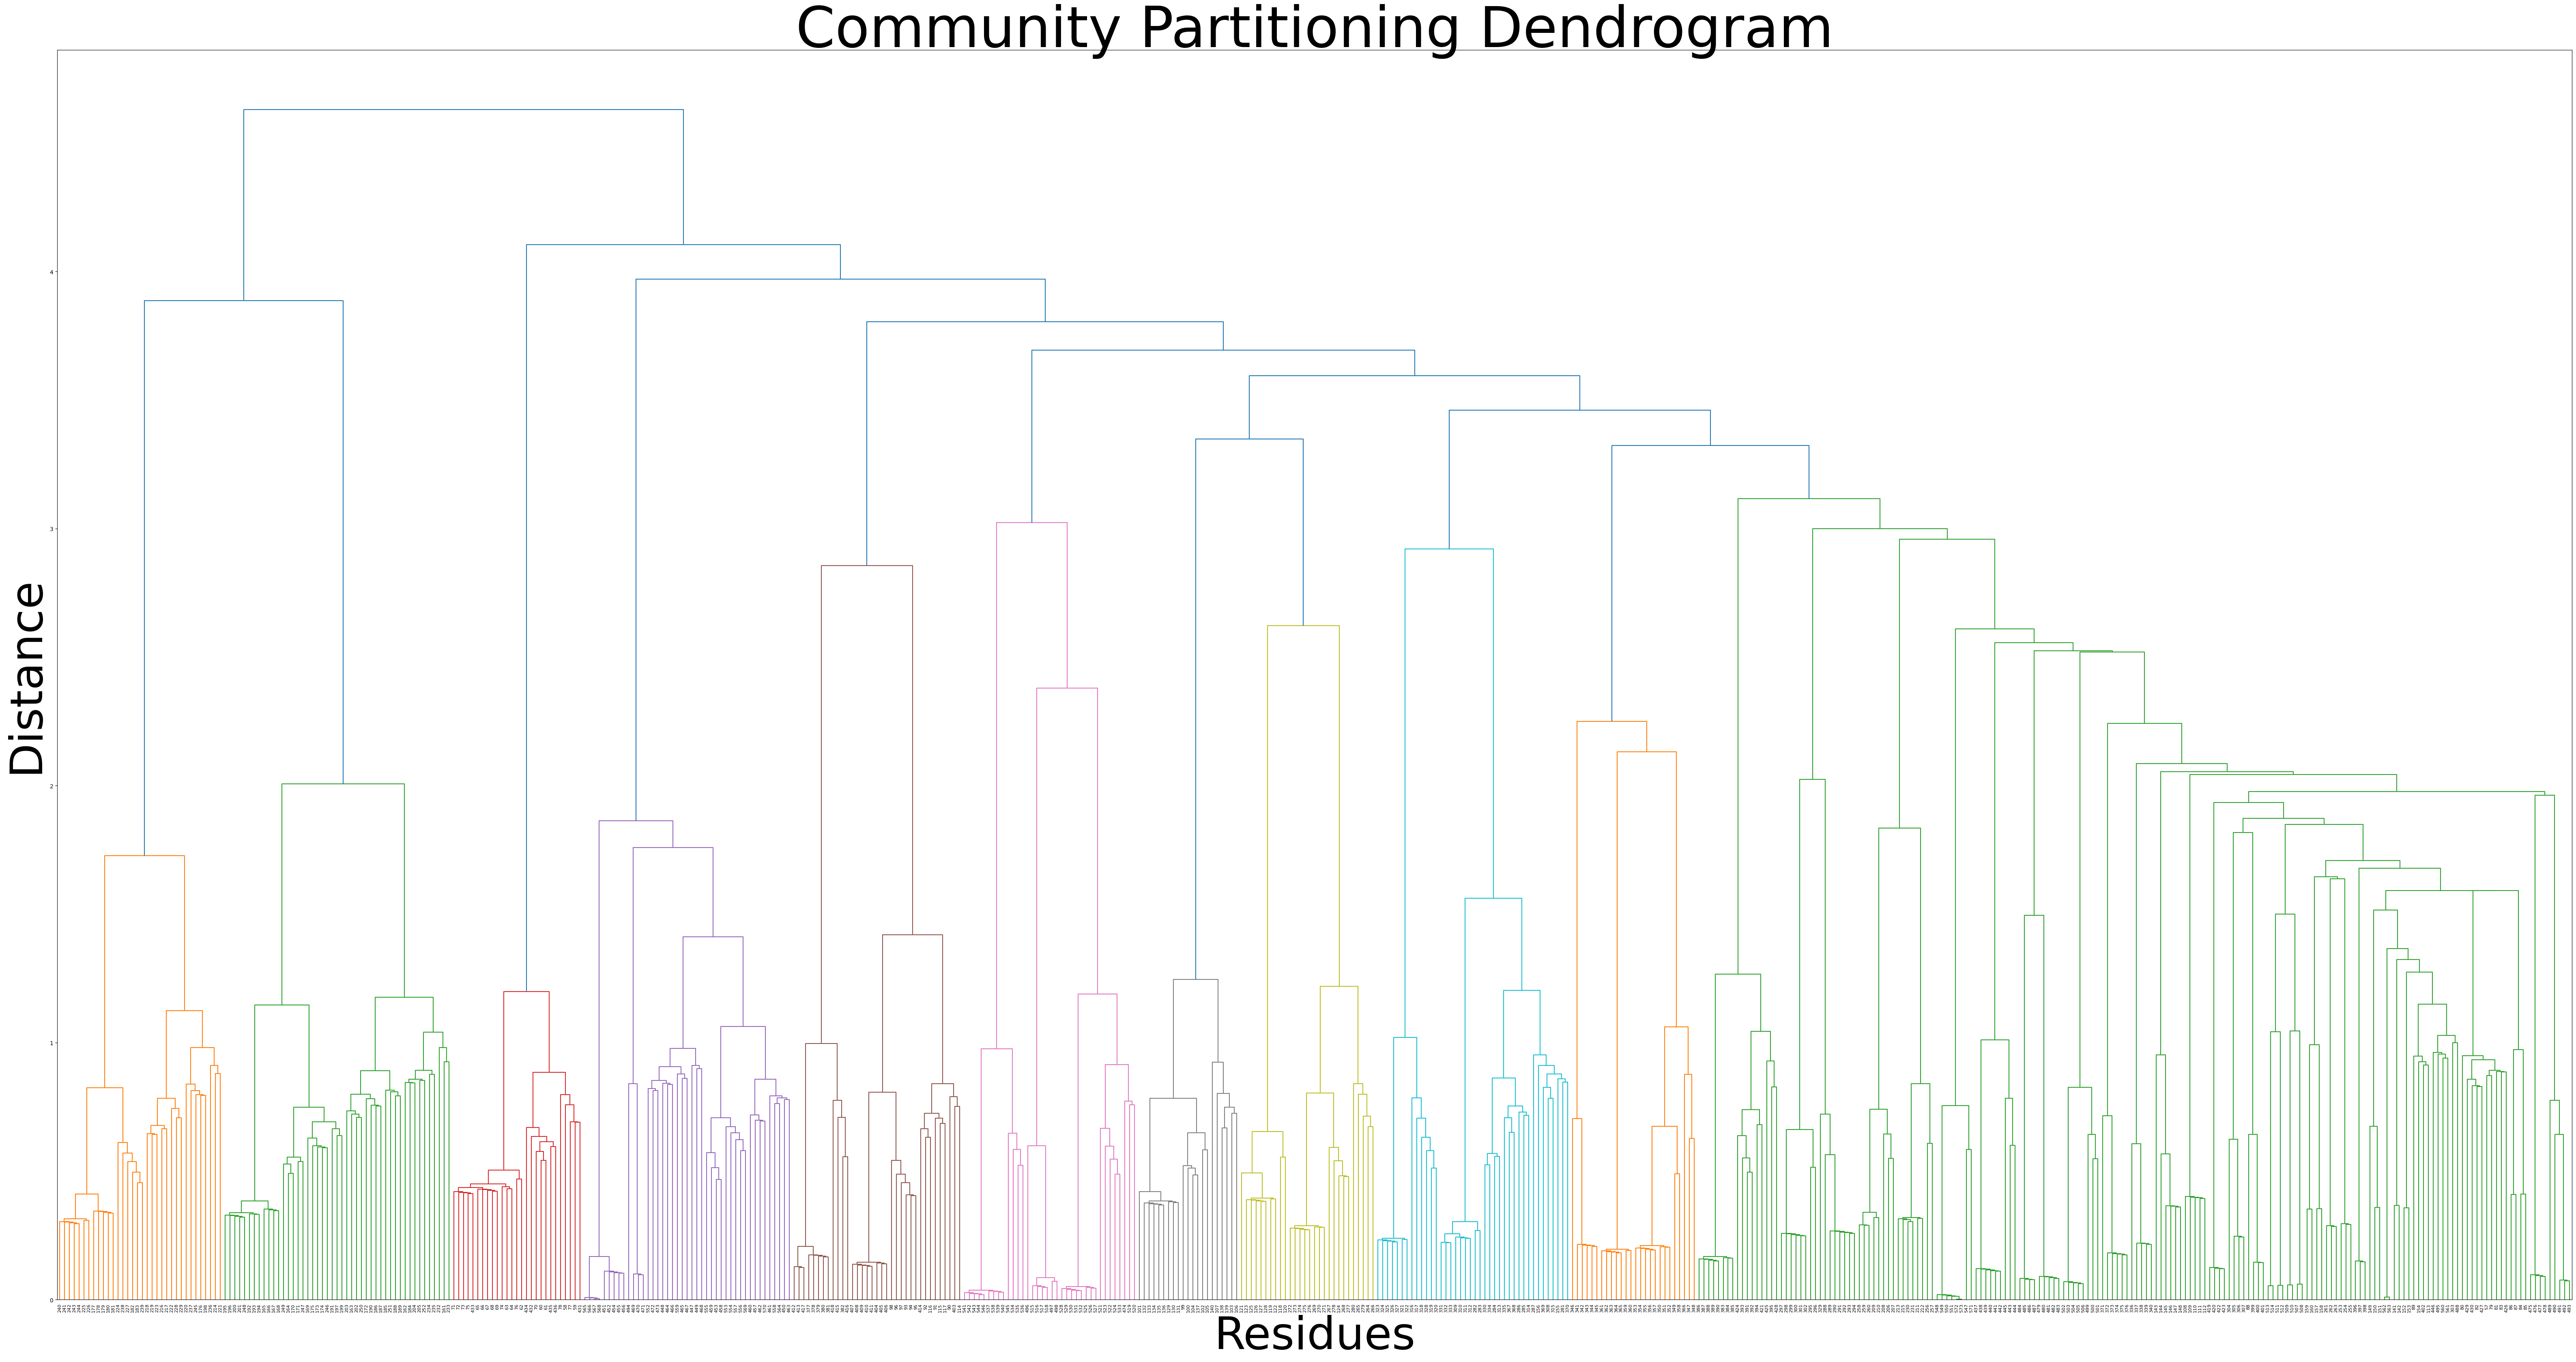

In [ ]:
plot_community_dendrogram(
    communities_results_path="output_communities.json",
    method="ward",
)


## Shortest Path Analysis

Shortest path analysis computes the minimal paths (by edge count or weights) between nodes, often representing efficient routes of energy or signal transfer. Short paths (low lengths) imply rapid and efficient propagation of signals or perturbations; long paths (high lengths) suggest indirect or inefficient communication, potentially indicating network disconnection. In MD, it's used to map allosteric pathways in proteins, showing how perturbations at one site propagate to another through correlated motions.


In [4]:
from biobb_dyna.dyna.analysis.shortest_paths import shortest_paths

prop = {
    "source_residue": 156,
    "sink_residue": 532,
    "num_paths": 200
}

shortest_paths(input_graph_path='output_graph.graphml',
              output_shortest_paths_path='output_shortest_paths.json',
              properties=prop)


2025-10-20 16:37:26,072 [MainThread  ] [INFO ]  Executing ShortestPaths analysis
2025-10-20 16:37:27,559 [MainThread  ] [INFO ]  ShortestPaths analysis complete.


0

### Path frequency per residue

Shortest path frequency (or participation) tracks how frequently nodes or edges appear on shortest paths network-wide. High frequency identifies highly utilized elements critical for multiple pathways; low frequency indicates rarely involved components, possibly redundant or specialized. In MD, this identifies residues or interactions repeatedly involved in dynamic pathways, pinpointing vulnerabilities or conserved elements in biomolecular mechanisms.

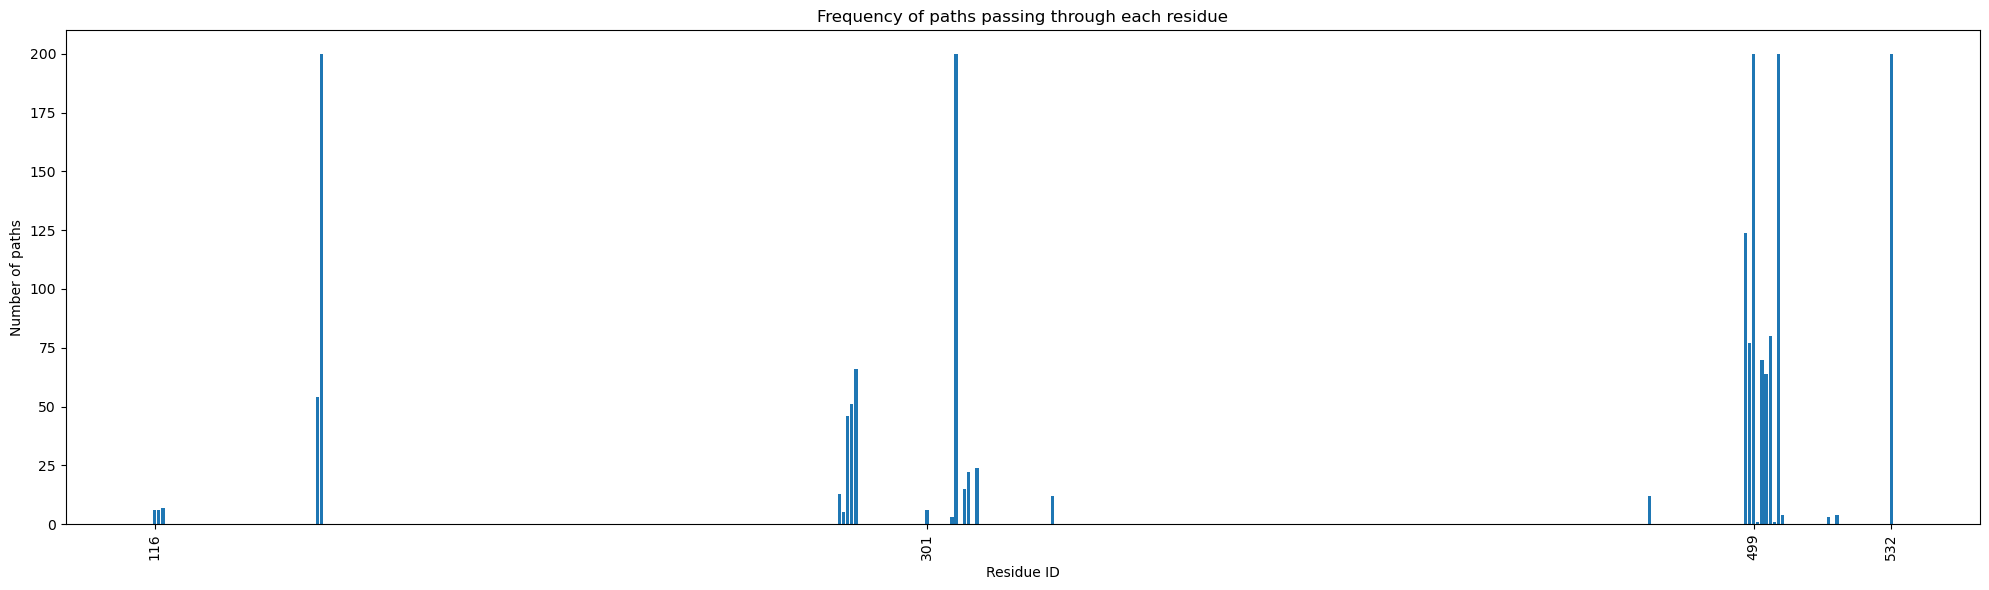

In [ ]:
plot_path_frequency_per_residue(
    shortest_paths_path="output_shortest_paths.json",
)

### Path length Distribution

Shortest path length distribution summarizes the average or histogram of shortest path lengths across the network, indicating overall connectivity and efficiency. A distribution skewed toward short lengths (low average) highlights "small-world" efficiency for quick dynamic responses; longer lengths (high average) point to a more fragmented or hierarchical network with delayed propagation. In MD networks, it helps characterize the "small-world" properties of protein dynamics, where short paths imply rapid communication essential for function.

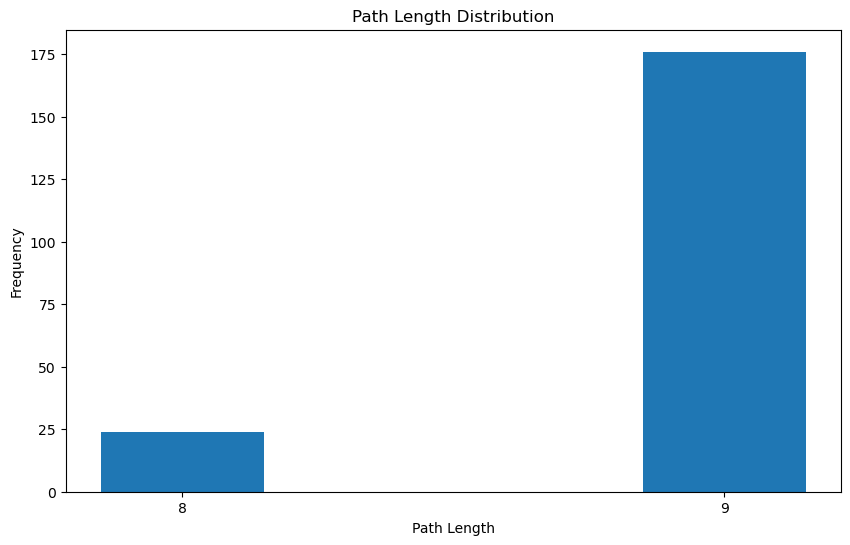

In [9]:
plot_shortest_path_length_distribution(
    shortest_paths_path="output_shortest_paths.json",
)

### Path Visualization

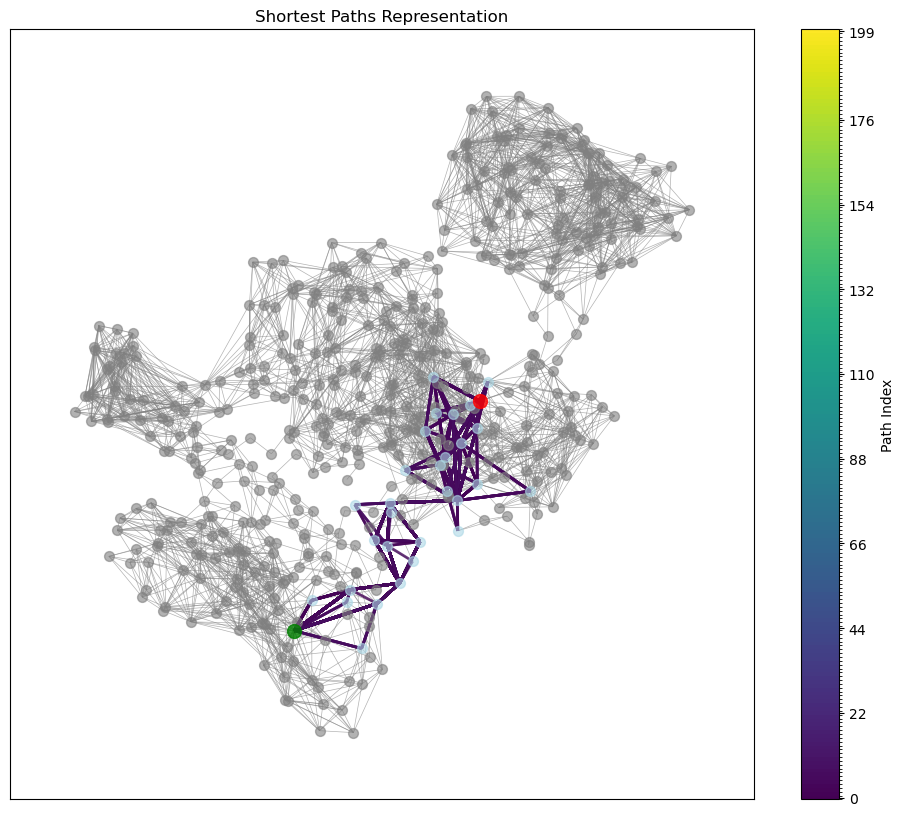

In [10]:
plot_shortest_paths(
    graph_path="output_graph.graphml",
    input_top_path="biobb_dyna/dyna/notebooks/dyna/data/WT_apo_CA_ChainA.pdb",
    shortest_paths_path="output_shortest_paths.json",
)